In [15]:
import os
import pandas as pd


In [16]:
df = pd.read_csv("~/Downloads/Cancer.csv")
print(df.head())

   samples   type  1007_s_at   1053_at    117_at    121_at  1255_g_at  \
0       84  basal   9.850040  8.097927  6.424728  7.353027   3.029122   
1       85  basal   9.861357  8.212222  7.062593  7.685578   3.149468   
2       87  basal  10.103478  8.936137  5.735970  7.687822   3.125931   
3       90  basal   9.756875  7.357148  6.479183  6.986624   3.181638   
4       91  basal   9.408330  7.746404  6.693980  7.333426   3.169923   

    1294_at   1316_at   1320_at  ...  AFFX-r2-Ec-bioD-3_at  \
0  6.880079  4.963740  4.408328  ...             12.229711   
1  7.542283  5.129607  4.584418  ...             12.178531   
2  6.562369  4.813449  4.425195  ...             12.125108   
3  7.802344  5.490982  4.567956  ...             12.111235   
4  7.610457  5.372469  4.424426  ...             12.173642   

   AFFX-r2-Ec-bioD-5_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
0             11.852955            13.658701            13.477698   
1             11.809408            13.750086      

In [32]:

X = df.drop(columns=["samples", "type"])
y = df["type"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

pca_pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full

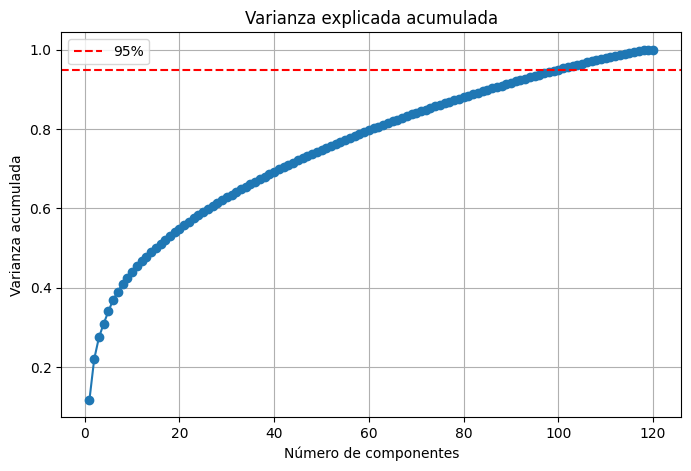

In [34]:
import numpy as np
import matplotlib.pyplot as plt

pca = pca_pipeline.named_steps["pca"]

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95%"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza explicada acumulada")
plt.legend()
plt.grid()
plt.show()

In [38]:
n_components = np.argmax(var >= 0.95) + 1
print(f"Componentes para 95% de varianza: {n_components}")

Componentes para 95% de varianza: 126


Se seleccionaron N componentes principales, ya que explican al menos el 95% de la varianza acumulada.

In [39]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(
            len(pca.components_)
        )
    ],
    index=X.columns
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC111,PC112,PC113,PC114,PC115,PC116,PC117,PC118,PC119,PC120
1007_s_at,0.003327,0.003235,0.003517,-0.007000,-0.002327,-0.010027,-0.007215,-0.000093,-0.003182,0.002648,...,-0.000894,0.005958,0.000241,0.000228,-0.000324,0.001952,-0.001233,0.004055,0.001072,0.070542
1053_at,-0.004699,-0.009754,-0.000269,-0.004258,-0.002572,-0.001326,0.001709,0.000005,-0.000463,-0.000811,...,0.005221,-0.002466,-0.001887,0.000281,0.000674,0.000665,0.000535,-0.000574,0.001908,-0.069134
117_at,-0.005028,0.004791,-0.002400,0.001470,-0.000849,-0.004557,0.008971,-0.001988,0.008725,-0.000475,...,0.006958,0.003558,-0.002065,-0.000800,0.004150,-0.006047,-0.001562,0.000378,-0.000912,-0.028969
121_at,0.006016,-0.003872,-0.001839,0.007545,-0.006290,0.003068,-0.001074,-0.003487,0.003530,-0.006736,...,0.004345,0.005046,-0.001059,-0.003225,-0.004373,-0.002639,-0.000874,0.002594,0.007719,0.186378
1255_g_at,0.004453,-0.002120,-0.006184,0.003956,-0.006589,-0.003815,0.000436,0.008548,0.003189,-0.002239,...,-0.005452,-0.000859,-0.001462,-0.006543,0.001213,0.006999,-0.001151,0.003824,0.004699,-0.066464


In [40]:
pc1 = (
    loadings["PC1"]
    .abs()
    .sort_values(
        ascending=False
    )
)

print(pc1.head(10))

220904_at       0.010709
1552889_a_at    0.010580
216102_at       0.010548
206849_at       0.010448
208260_at       0.010372
225952_at       0.010273
206119_at       0.010262
239592_at       0.010257
1569393_at      0.010245
242921_at       0.010227
Name: PC1, dtype: float64


In [41]:
pc2 = (
    loadings["PC2"]
    .abs()
    .sort_values(
        ascending=False
    )
)

print(pc2.head(10))

200795_at      0.012499
222358_x_at    0.012250
201744_s_at    0.012209
211161_s_at    0.012132
202283_at      0.012114
223122_s_at    0.012099
241993_x_at    0.012083
201893_x_at    0.012039
241777_x_at    0.012037
211896_s_at    0.012024
Name: PC2, dtype: float64
